In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


%matplotlib inline

In [3]:
url1 = 'https://stepik.org/media/attachments/lesson/360348/user_data.csv'
url2 = 'https://stepik.org/media/attachments/lesson/360348/logs.csv'

user_data = pd.read_csv(url1)
logs = pd.read_csv(url2)



In [4]:
# Looking through data

In [5]:
user_data.head()

,client,premium,age
0,46346,False,58
1,4391,False,55
2,27372,False,64
3,11989,False,44
4,60664,False,49


In [6]:
user_data.shape

(2954, 3)

In [7]:
user_data.dtypes

client     int64
premium     bool
age        int64
dtype: object

In [8]:
user_data.describe()

,client,age
count,2954.000000,2954.000000
mean,50767.886594,44.196005
std,28800.505847,14.248336
min,40.000000,20.000000
25%,25639.500000,32.000000
50%,51569.500000,44.000000
75%,75963.250000,56.000000
max,99973.000000,69.000000


In [9]:
logs.head()

,client,success,platform,time
0,40177,True,phone,1585412212
1,61468,True,phone,1585425658
2,35604,False,phone,1585459894
3,9961,True,phone,1585400189
4,10931,True,computer,1585468629


In [10]:
logs.shape

(4500, 4)

In [11]:
logs.dtypes

client       int64
success       bool
platform    object
time         int64
dtype: object

In [12]:
logs.describe()

,client,time
count,4500.000000,4.500000e+03
mean,50998.758000,1.585440e+09
std,28374.472495,2.314866e+04
min,40.000000,1.585400e+09
25%,27056.500000,1.585420e+09
50%,52659.000000,1.585440e+09
75%,76001.250000,1.585461e+09
max,99993.000000,1.585480e+09


In [13]:
# Number of unique values in platform
logs.platform.value_counts().count()

3

In [14]:
# find all clients with maximum number of successes
successes = logs.query('success')\
                .groupby('client', as_index = False)\
                .agg({'platform':'count'})\
                .rename(columns = {'platform':'success'})

max_success = successes['success'].max()


In [15]:
 list(successes[successes['success'] == max_success]['client'])

[12179, 28719, 36165, 52870, 61468, 61473, 78349, 82563, 92584]

In [16]:
# On which platform is there the maximum number of successful operations?
logs.groupby('platform')\
    .agg({'success':'sum'})\
    .sort_values('success', ascending = False)

,success
platform,
phone,2019
computer,1090
tablet,180


In [17]:
# which platform is the most popular among premium clients?

# inner join the tables
full_user_info = user_data.merge(logs, on = 'client')
full_user_info.head()

,client,premium,age,success,platform,time
0,46346,False,58,True,phone,1585452839
1,4391,False,55,False,phone,1585409861
2,27372,False,64,False,phone,1585446018
3,11989,False,44,True,computer,1585403698
4,60664,False,49,True,phone,1585406918


In [18]:
full_user_info.query('premium')\
              .groupby('platform',as_index = False)\
              .agg({'client':'count'})\
              .sort_values('client',ascending = False)
              

,platform,client
1,phone,246
0,computer,150
2,tablet,24


d:\python3.8\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
d:\python3.8\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='age', ylabel='Density'>

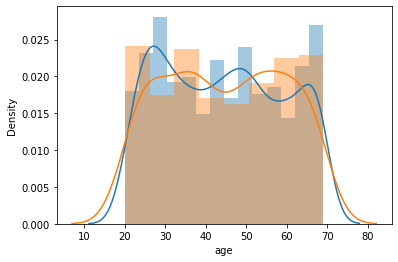

In [19]:
# visualize the number of clients with respect to his status and age

sns.distplot(full_user_info[full_user_info['premium'] == False].age, kde = True)
sns.distplot(full_user_info[full_user_info['premium']].age, kde = True)# premium clients


In [20]:
# visualize the distribution of the number of success operations to the number of clients that made these operations

# group by clients, calculate the number or successful operation of each client

successes = logs.query('success')\
    .groupby('client',as_index=False)\
    .agg({'platform':'count'})\
    .rename(columns = {'platform':'success_amt'})


In [21]:
successes.describe()

,client,success_amt
count,2845.000000,2845.000000
mean,50158.268190,1.156063
std,28769.099737,2.364374
min,40.000000,1.000000
25%,24839.000000,1.000000
50%,50649.000000,1.000000
75%,74971.000000,1.000000
max,99993.000000,41.000000


<AxesSubplot:xlabel='success_amt', ylabel='count'>

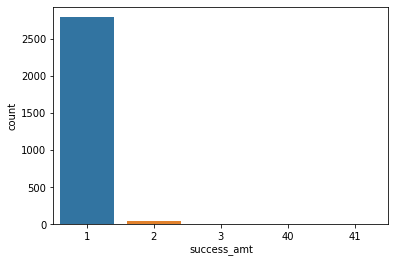

In [22]:
sns.countplot(x = 'success_amt', data = successes)

<AxesSubplot:xlabel='age', ylabel='count'>

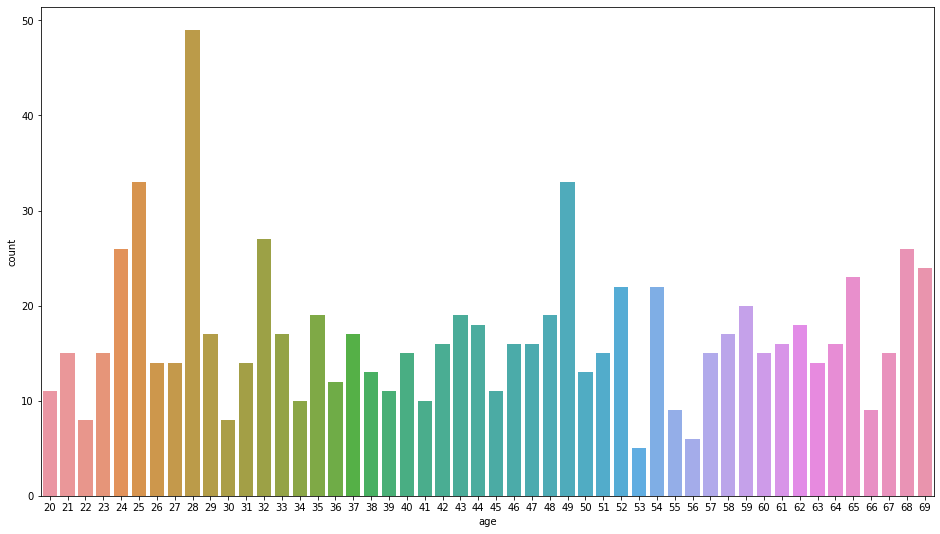

In [23]:
# visualize the number of scuccessful operations on the platform computer to  users' age

# take successful operations on computer platform
# group by client and count records

#full_user_info.query("success and platform == 'computer'")\
#              .groupby('age')\
#              .agg({'client':'count'})


# but countplot makes the same
plt.figure(figsize = (16,9))

sns.countplot(x = 'age', data=full_user_info.query("success and platform == 'computer'"))